In [1]:
import numpy as np
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import umap

In [2]:
training_bubble = np.load("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/analysis/check_latent/latent_list/fgn_latent/FGN_01100-02900_bubble.npy")
training_data = np.load("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/analysis/check_latent/latent_list/fgn_latent/FGN_01100-02900.npy")
test_03300_bubble = np.load("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/analysis/check_latent/latent_list/fgn_latent/FGN_03300+0000_test_bubble.npy")
test_03300_data = np.load("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/analysis/check_latent/latent_list/fgn_latent/FGN_03300+0000_test.npy")
test_03400_bubble = np.load("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/analysis/check_latent/latent_list/fgn_latent/FGN_03400+0000_test_bubble.npy")
test_03400_data = np.load("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/analysis/check_latent/latent_list/fgn_latent/FGN_03400+0000_test.npy")

In [3]:
training_bubble_label = [0] * len(training_bubble)
training_data_label = [1] * len(training_data)

test_03300_bubble_label = [0] * len(test_03300_bubble)
test_03300_data_label = [1] * len(test_03300_data)

test_03400_bubble_label = [0] * len(test_03400_bubble)
test_03400_data_label = [1] * len(test_03400_data)

In [4]:
print(len(training_bubble))
print(len(training_data))

1179
7074


In [5]:
# trainig_dataのまとめ
training_data_set = np.concatenate((training_bubble, training_data))
training_labels_set = np.concatenate((training_bubble_label, training_data_label))

# FGN_03300まとめ
test_03300_data_set = np.concatenate((test_03300_bubble, test_03300_data))
test_03300_labels_set = np.concatenate((test_03300_bubble_label, test_03300_data_label))

# FGN_03400まとめ
test_03400_data_set = np.concatenate((test_03400_bubble, test_03400_data))
test_03400_labels_set = np.concatenate((test_03400_bubble_label, test_03400_data_label))

# 全データまとめ
all_data_set = np.concatenate((training_data_set, test_03300_data_set, test_03400_data_set))
all_labels_set = np.concatenate((training_labels_set, test_03300_labels_set, test_03400_labels_set))

In [6]:
# 1. UMAPのモデルを作成
# 基本はデフォルト設定のままで強力に機能します
n_neighbors = 3
min_dist = 0.1
random_state = 43
reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, random_state=random_state)

# 2. 100次元のデータを2次元に変換（低次元空間への埋め込み）
embedding = reducer.fit_transform(training_data_set)

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [20]:
print(len(training_data_set))
print(len(test_03300_data_set))
print(len(test_03400_data_set))
print(len(all_data_set))

8253
138
168
8559


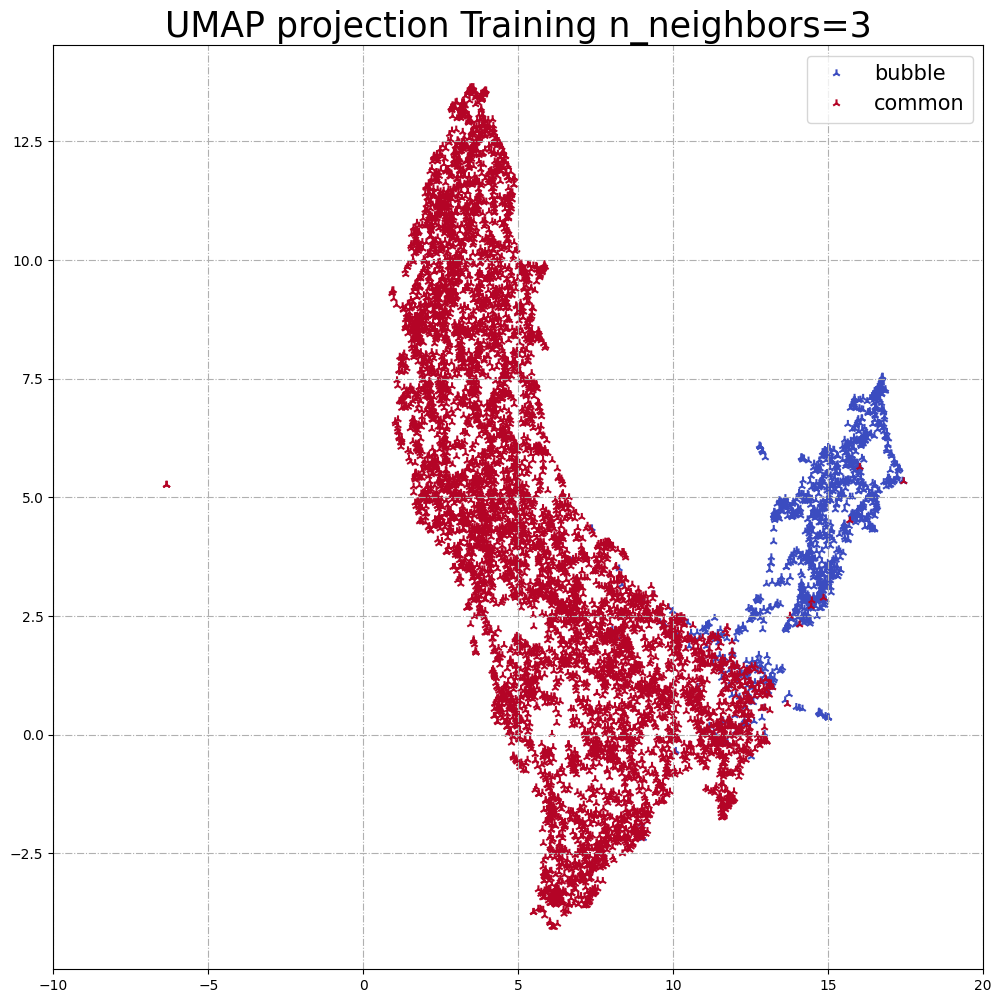

In [7]:
# 4. 2次元になったデータをグラフに描画
plt.figure(figsize=(12, 12))

# ※ c に渡すデータは数値（例: no=0, bubble=1）に変換されている前提です
scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=training_labels_set,
    cmap="coolwarm",  # 2クラスなら「赤・青」に分かれる bwr や coolwarm などが見やすいです
    marker="2",
)

# --- 凡例（Legend）の追加処理 ---
handles, _ = scatter.legend_elements()
plt.legend(handles, ["bubble", "common"], loc="upper right", fontsize=15)
# --------------------------------
plt.xlim(-10, 20)
plt.title(f"UMAP projection Training n_neighbors={n_neighbors}", fontsize=25)
plt.grid(ls="dashdot")
plt.savefig(f"UMAP_projection_Training_n_neighbors{n_neighbors}_min_dist{min_dist}_random_state{random_state}.png")
plt.show()

In [8]:
# 03300に対するfitting
embedding_03300 = reducer.transform(test_03300_data_set)

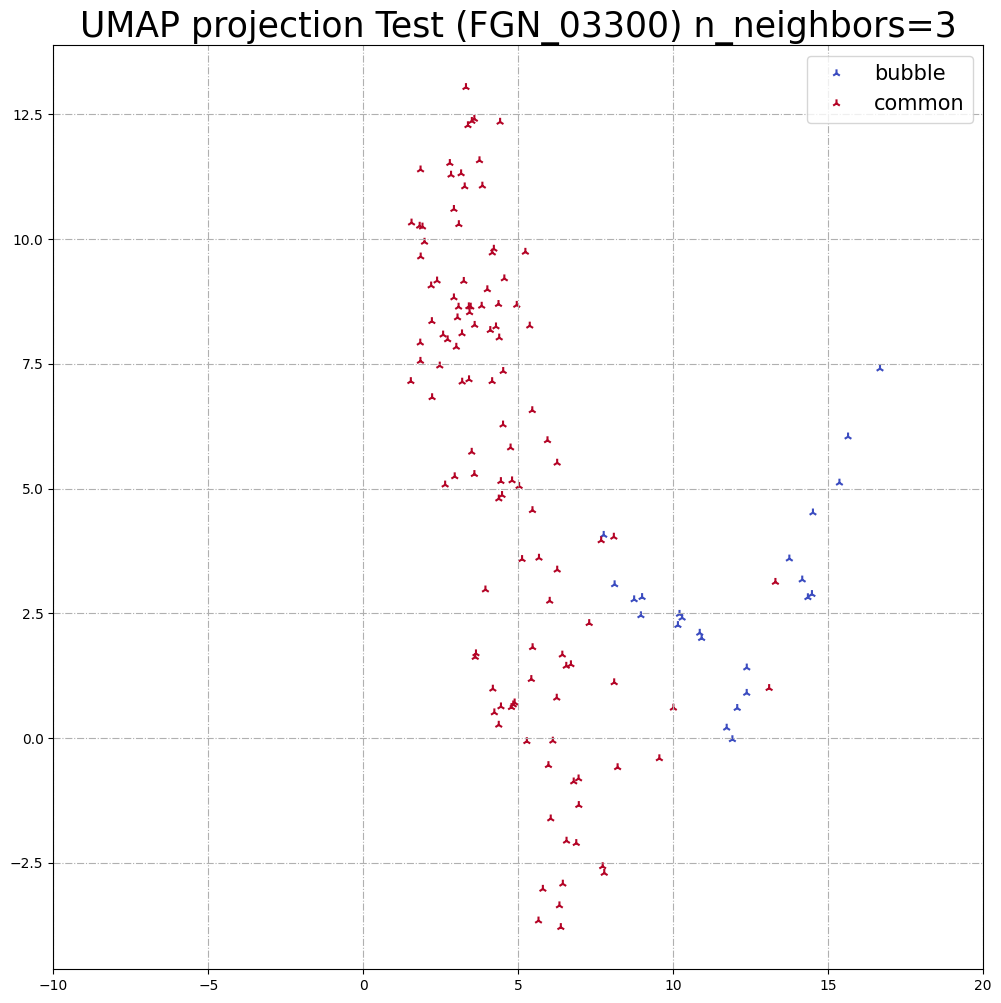

In [9]:
# 4. 2次元になったデータをグラフに描画
plt.figure(figsize=(12, 12))

# ※ c に渡すデータは数値（例: no=0, bubble=1）に変換されている前提です
scatter = plt.scatter(
    embedding_03300[:, 0],
    embedding_03300[:, 1],
    c=test_03300_labels_set,
    cmap="coolwarm",  # 2クラスなら「赤・青」に分かれる bwr や coolwarm などが見やすいです
    marker="2",
)

# --- 凡例（Legend）の追加処理 ---
handles, _ = scatter.legend_elements()
plt.legend(handles, ["bubble", "common"], loc="upper right", fontsize=15)
# --------------------------------
plt.xlim(-10, 20)
plt.title(f"UMAP projection Test (FGN_03300) n_neighbors={n_neighbors}", fontsize=25)
plt.grid(ls="dashdot")
plt.savefig(f"UMAP_projection_FGN_03300_n_neighbors{n_neighbors}_min_dist{min_dist}_random_state{random_state}.png")
plt.show()

In [10]:
# 03400に対するfitting
embedding_03400 = reducer.transform(test_03400_data_set)

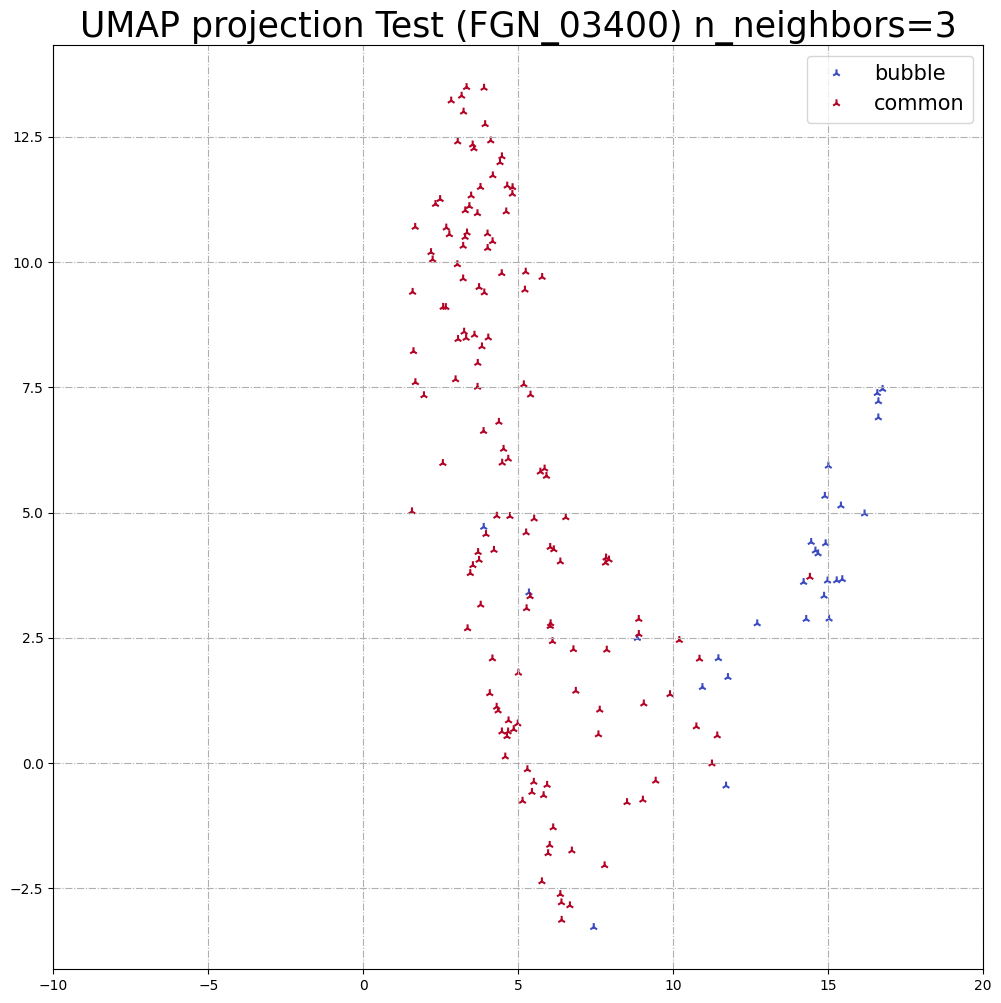

In [11]:
# 4. 2次元になったデータをグラフに描画
plt.figure(figsize=(12, 12))

# ※ c に渡すデータは数値（例: no=0, bubble=1）に変換されている前提です
scatter = plt.scatter(
    embedding_03400[:, 0],
    embedding_03400[:, 1],
    c=test_03400_labels_set,
    cmap="coolwarm",  # 2クラスなら「赤・青」に分かれる bwr や coolwarm などが見やすいです
    marker="2",
)

# --- 凡例（Legend）の追加処理 ---
handles, _ = scatter.legend_elements()
plt.legend(handles, ["bubble", "common"], loc="upper right", fontsize=15)
# --------------------------------
plt.xlim(-10, 20)
plt.title(f"UMAP projection Test (FGN_03400) n_neighbors={n_neighbors}", fontsize=25)
plt.grid(ls="dashdot")
plt.savefig(f"UMAP_projection_FGN_03400_n_neighbors{n_neighbors}_min_dist{min_dist}_random_state{random_state}.png")
plt.show()

In [12]:
# 全データセットに対するfitting
embedding_all = reducer.transform(all_data_set)

In [18]:
len(embedding_all)

8559

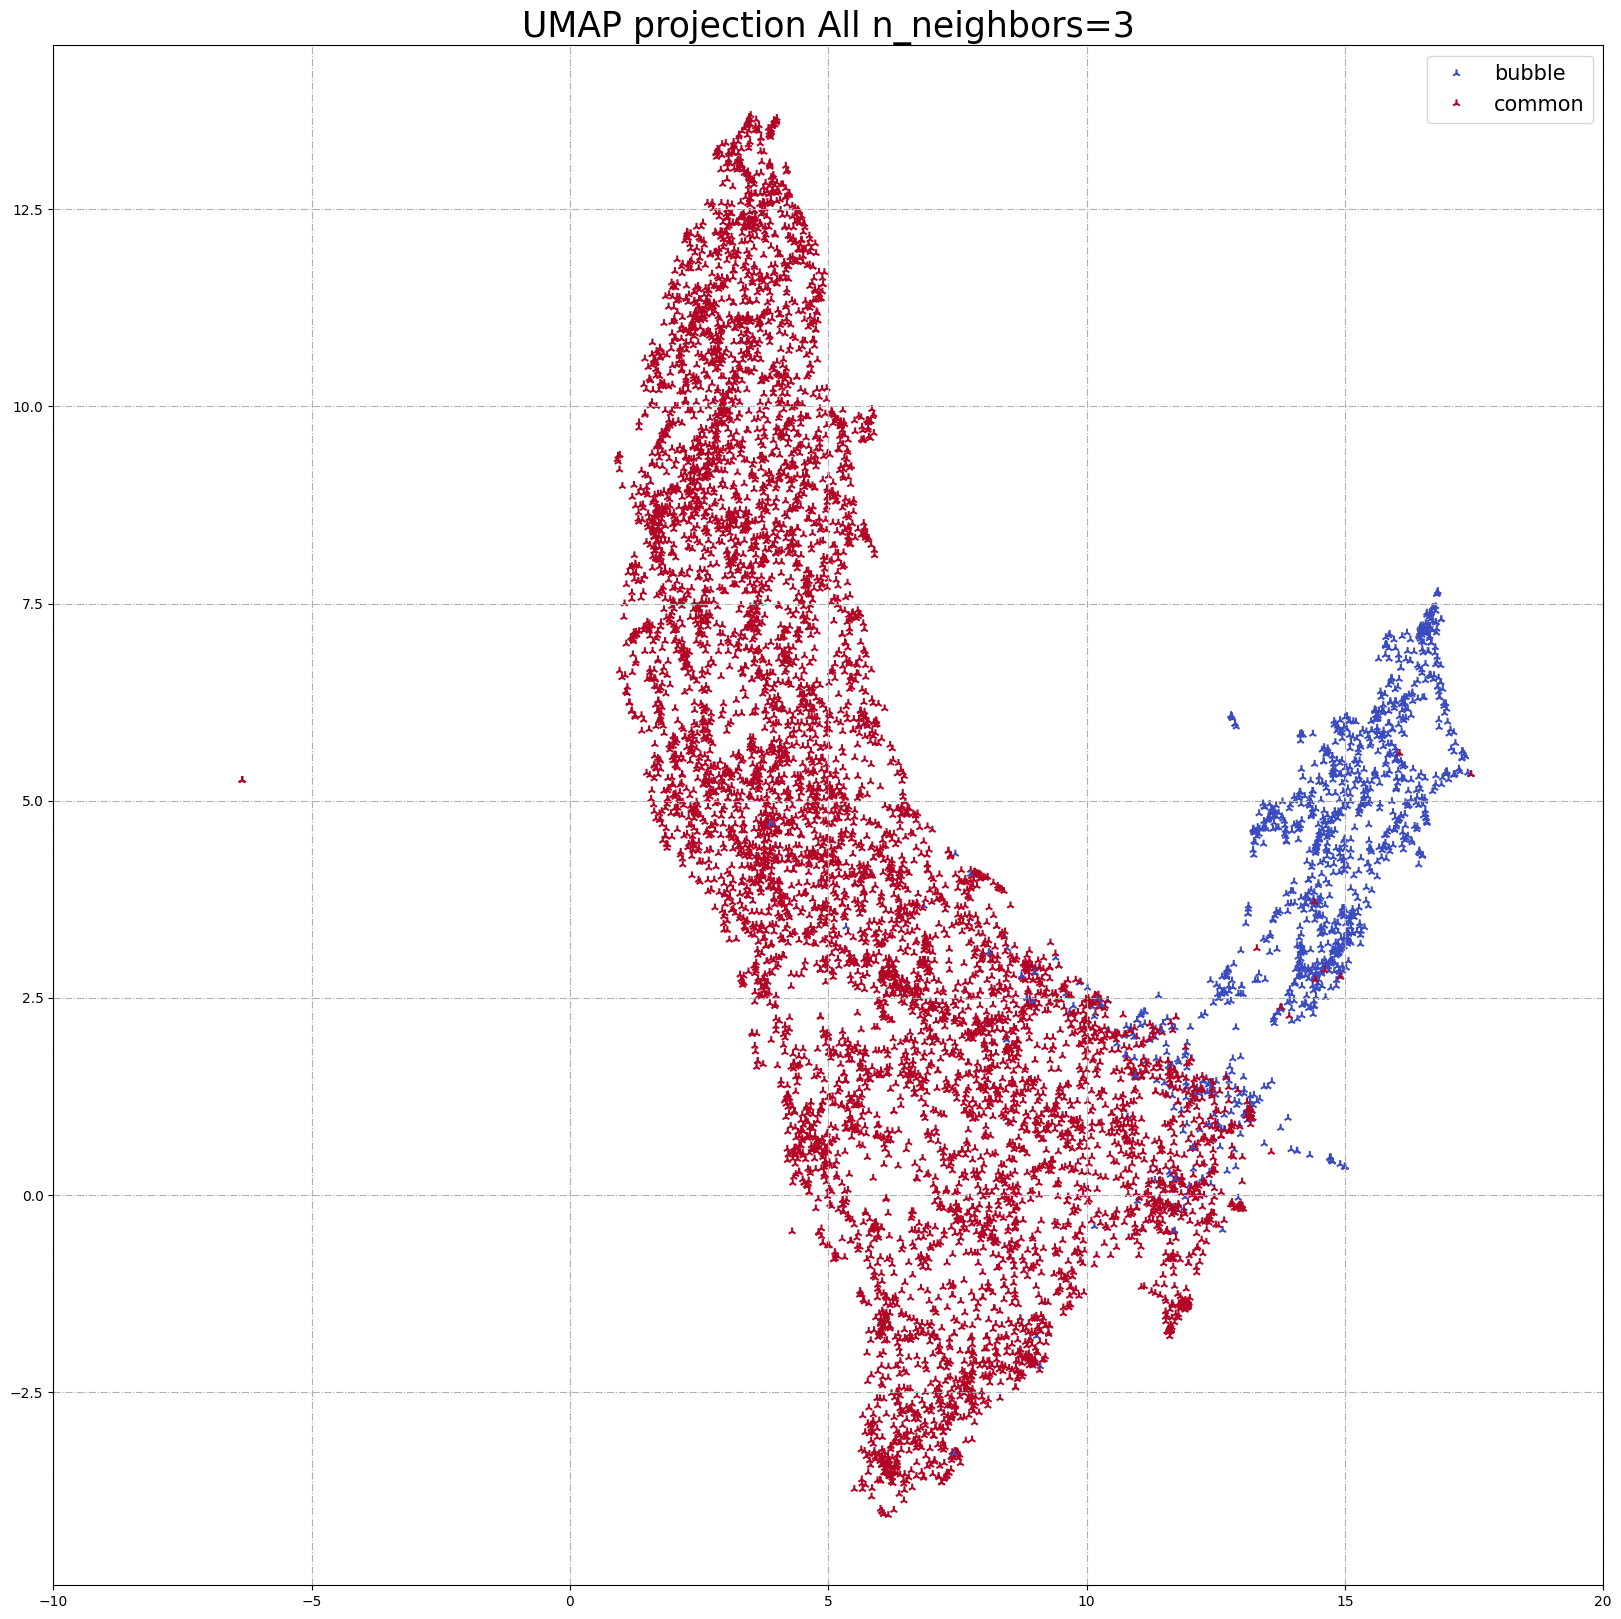

In [17]:
# 4. 2次元になったデータをグラフに描画
plt.figure(figsize=(20, 20))

# ※ c に渡すデータは数値（例: no=0, bubble=1）に変換されている前提です
scatter = plt.scatter(
    embedding_all[:, 0],
    embedding_all[:, 1],
    c=all_labels_set,
    cmap="coolwarm",  # 2クラスなら「赤・青」に分かれる bwr や coolwarm などが見やすいです
    marker="2",
)

# --- 凡例（Legend）の追加処理 ---
handles, _ = scatter.legend_elements()
plt.legend(handles, ["bubble", "common"], loc="upper right", fontsize=15)
# --------------------------------
plt.xlim(-10, 20)
plt.title(f"UMAP projection All n_neighbors={n_neighbors}", fontsize=25)
plt.grid(ls="dashdot")
# plt.savefig(f"UMAP_projection_All_n_neighbors{n_neighbors}_min_dist{min_dist}_random_state{random_state}.png")
plt.show()

# ダミーデータを入れてプロット

In [14]:
# 1. 100次元の特徴量を持つダミーデータを100個作成とラベル作成
# 仕様の定義
n_samples = 10000
n_features = 100   # 100個の特徴量（次元）

# 最大値と最小値を指定
min_val = np.min(all_data_set)
max_val = np.max(all_data_set)
print(min_val, max_val)

# 0〜1の乱数に幅を掛け算し、最小値を足すことで範囲を制御
X_dummy = np.random.uniform(low=min_val, high=max_val, size=(n_samples, n_features))

# ラベル作成
dummy_labels = [3]*n_samples

# 2
all_and_dummy = np.concatenate((all_data_set, X_dummy))
all_and_dummy_labels = np.concatenate((all_labels_set, dummy_labels))

# 3. 学習済みモデル（reducer）を使って、ダミーデータを2次元空間に変換（transform）
embedding_dummy = reducer.transform(all_and_dummy)

0.0 10.6822605


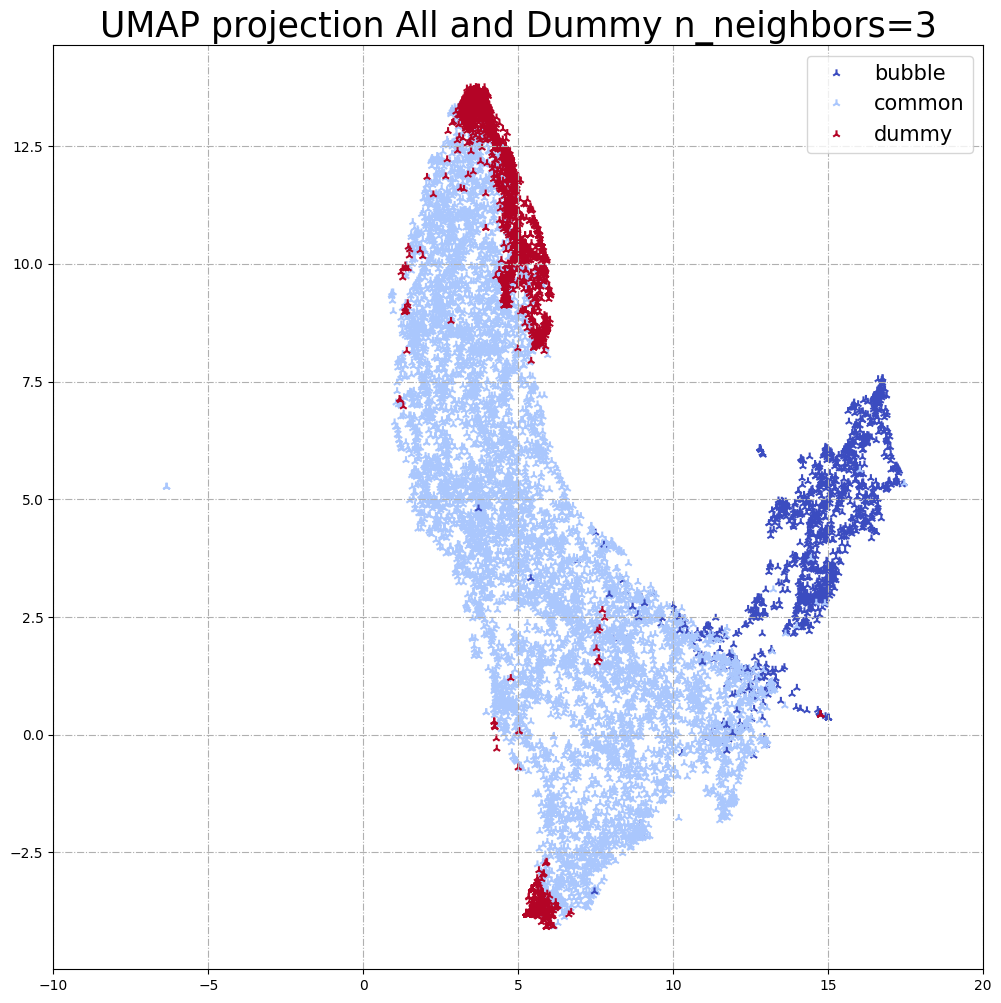

In [15]:
# 4. 2次元になったデータをグラフに描画
plt.figure(figsize=(12, 12))

# ※ c に渡すデータは数値（例: no=0, bubble=1）に変換されている前提です
scatter = plt.scatter(
    embedding_dummy[:, 0],
    embedding_dummy[:, 1],
    c=all_and_dummy_labels,
    cmap="coolwarm",  # 2クラスなら「赤・青」に分かれる bwr や coolwarm などが見やすいです
    marker="2",
)

# --- 凡例（Legend）の追加処理 ---
handles, _ = scatter.legend_elements()
plt.legend(handles, ["bubble", "common", "dummy"], loc="upper right", fontsize=15)
# --------------------------------
plt.xlim(-10, 20)
plt.title(f"UMAP projection All and Dummy n_neighbors={n_neighbors}", fontsize=25)
plt.grid(ls="dashdot")
plt.savefig(f"UMAP_projection_All_and_Dummy_n_neighbors{n_neighbors}_min_dist{min_dist}_random_state{random_state}.png")
plt.show()

# 謎のデータの正体を確かめる

In [16]:
from tqdm.notebook import tqdm
import os

In [17]:
# 1. 2次元座標（embedding_all）から、左側に孤立している点の条件を指定
# X座標が -5 未満、かつ Y座標が 4以上6以下 のデータを探索
condition = (embedding_all[:, 0] < -5) & (embedding_all[:, 1] >= 5) & (embedding_all[:, 1] <= 6)

# 2. 条件を満たすデータのインデックス（何番目か）を取得
isolated_indices = np.where(condition)[0]

print("該当するデータのインデックス（何番目か）:", isolated_indices)

該当するデータのインデックス（何番目か）: [4204 5965 7526]


In [18]:
def reload_trainig_data(region_dict):
    all_selected_data = []
    # 領域ごとのカウントを保持するリストを別途作成
    counts_per_reg = []

    for reg, num_to_sample in tqdm(region_dict.items()):
        combined_region_data = None

        path = f"{base_path}/{reg}/thresh_up_low/lower-1.66_data.npy"
        if os.path.exists(path):
            combined_region_data = np.load(path)

        # --- サンプリング処理 ---
        if combined_region_data is not None and len(combined_region_data) > 0:
            random_indices_path = f"/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/training/training_data_indices/{reg}/binary_model_lower_rank1_pos-neg_is_1_train-FGN_01100-02900_val-FGN03100.npy"
            indices = np.load(random_indices_path)
            sampled = combined_region_data[indices]
            all_selected_data.append(sampled) # データがある時だけリストに入れる
            counts_per_reg.append(len(sampled)) # 実際のサンプル数を記録
        else:
            # データがない場合はリストに追加せず、カウントだけ 0 にする
            counts_per_reg.append(0)

    return np.concatenate(all_selected_data) if all_selected_data else np.array([]), counts_per_reg

In [19]:
# 基本設定
base_path = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/processed_data"

# 領域ごとのロード設定 (領域名: 抽出したいデータ数)
# もし全データロードしたい場合は None や非常に大きい数値を指定してください
data_num = 700
target_regions = {
    "FGN_01100+0000": data_num,
    "FGN_01200+0000": data_num,
    "FGN_01300+0000": data_num,
    "FGN_01400+0000": data_num,
    "FGN_01500+0000": data_num,
    "FGN_01600+0000": data_num,
    "FGN_01700+0000": data_num,
    "FGN_01800+0000": data_num,
    "FGN_01900+0000": data_num,
    "FGN_02000+0000": data_num,
    "FGN_02100+0000": data_num,
    "FGN_02200+0000": data_num,
    "FGN_02300+0000": data_num,
    "FGN_02400+0000": data_num,
    "FGN_02500+0000": data_num,
    "FGN_02600+0000": data_num,
    "FGN_02700+0000": data_num,
    "FGN_02800+0000": data_num,
    "FGN_02900+0000": data_num,
}

# バブルのランク設定
bubble_config = {
    "FGN_01100+0000": ["Rank1"],
    "FGN_01200+0000": ["Rank1"],
    "FGN_01300+0000": ["Rank1"],
    "FGN_01400+0000": ["Rank1"],
    "FGN_01500+0000": ["Rank1"],
    "FGN_01600+0000": ["Rank1"],
    "FGN_01700+0000": ["Rank1"],
    "FGN_01800+0000": ["Rank1"],
    "FGN_01900+0000": ["Rank1"],
    "FGN_02000+0000": ["Rank1"],
    "FGN_02100+0000": ["Rank1"],
    "FGN_02200+0000": ["Rank1"],
    "FGN_02300+0000": ["Rank1"],
    "FGN_02400+0000": ["Rank1"],
    "FGN_02500+0000": ["Rank1"],
    "FGN_02600+0000": ["Rank1"],
    "FGN_02700+0000": ["Rank1"],
    "FGN_02800+0000": ["Rank1"],
    "FGN_02900+0000": ["Rank1"],
    "FGN_03100+0000": ["Rank1", "Rank2", "Rank3"],
    # "FGN_03200+0000": ["Rank1", "Rank2", "Rank3"],
    "FGN_03300+0000": ["Rank1", "Rank2", "Rank3"],
    # "FGN_03400+0000": ["Rank1", "Rank2", "Rank3"]
}

In [20]:
def load_bubble_data(region_dict, bubble_filename="slide_bubble_data.npy"):
    all_selected_data = []
    # 領域ごとのカウントを保持するリストを別途作成
    counts_per_reg = []

    for reg, num_to_sample in tqdm(region_dict.items()):
        combined_region_data = None
        
        region_data_list = []
        ranks = bubble_config.get(reg, [])
        for rank in ranks:
            path = f"{base_path}/{reg}/Rank_Bubble/{rank}/{bubble_filename}"
            if os.path.exists(path):
                region_data_list.append(np.load(path))
            else:
                print(f"Info: No data for {reg} {rank}. Skipping append.")
        if region_data_list:
            combined_region_data = np.concatenate(region_data_list)

        if combined_region_data is not None and len(combined_region_data) > 0:
            all_selected_data.append(combined_region_data) # データがある時だけリストに入れる
            counts_per_reg.append(len(combined_region_data)) # 実際のサンプル数を記録
        else:
            # データがない場合はリストに追加せず、カウントだけ 0 にする
            counts_per_reg.append(0)

    # データのリスト, 個数のリスト, インデックス番号
    return all_selected_data, counts_per_reg

In [21]:
training_data2, training_count = reload_trainig_data(target_regions)

  0%|          | 0/19 [00:00<?, ?it/s]

In [28]:
all_bubble_request = {reg: 999999 for reg in target_regions.keys()}
training_bubble2, bubble_count = load_bubble_data(all_bubble_request)
training_bubble2 = np.concatenate(training_bubble2)

  0%|          | 0/19 [00:00<?, ?it/s]

Info: No data for FGN_01600+0000 Rank1. Skipping append.


In [57]:
print(len(training_bubble2))
print(len(training_data2))
training_data_to_check_isolate = np.concatenate((training_bubble2, training_data2))

1179
7074


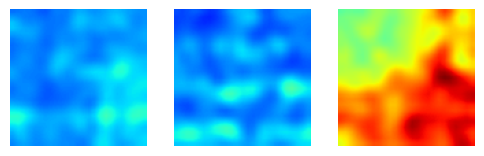

In [58]:
isolated_data = training_data_to_check_isolate[isolated_indices]

fig, axes = plt.subplots(1, len(isolated_data), figsize=(2*len(isolated_data), 2))
axes_flat = axes.flatten()
for i in range(len(isolated_data)):
    ax = axes_flat[i]
    data = isolated_data[i]
    ax.imshow(np.sum(data, axis=0), cmap="jet", vmin=0, vmax=10)
    ax.axis("off")
plt.savefig("isolate_data.png")
plt.show()

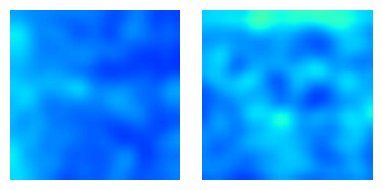

In [68]:
ex_num1 = 4000
ex_num2 = 5000

common_ex = training_data_to_check_isolate[[ex_num1, ex_num2]]

fig, axes = plt.subplots(1, len(common_ex), figsize=(2*len(common_ex), 2))
axes_flat = axes.flatten()
for i in range(len(common_ex)):
    ax = axes_flat[i]
    data = common_ex[i]
    ax.imshow(np.sum(data, axis=0), cmap="jet", vmin=0, vmax=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig("common_ex_data.png")
plt.show()

30


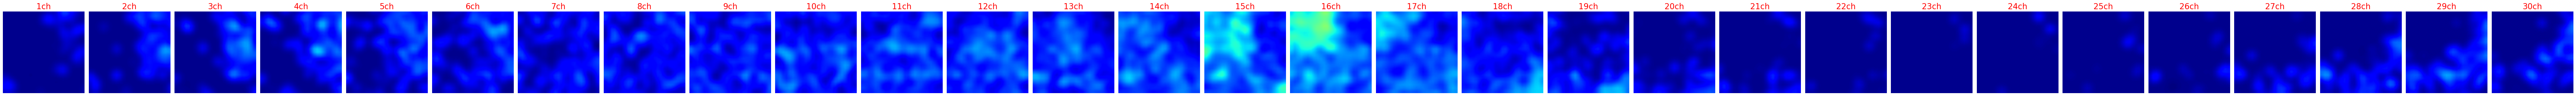

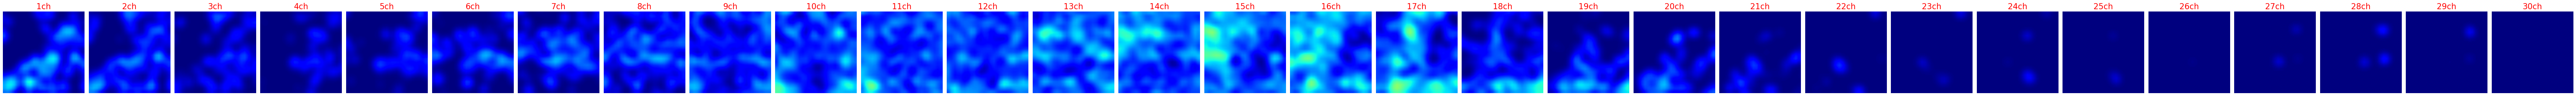

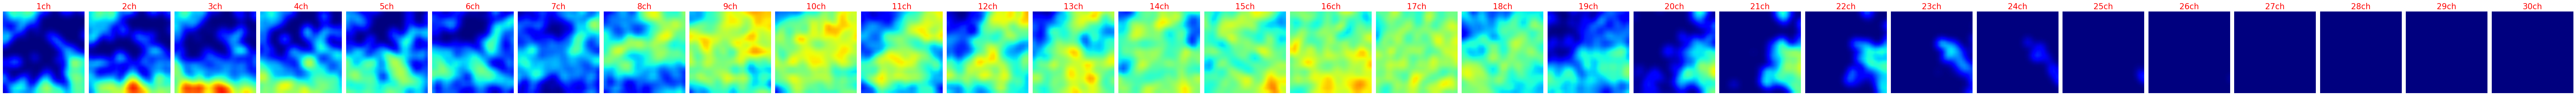

In [69]:
axes_num = isolated_data[0].shape[0]
print(axes_num)

for index in range(len(isolated_data)):
    data = isolated_data[index]
    
    fig, axes = plt.subplots(1, axes_num, figsize=(axes_num*3, 1*4))
    for j, data_segment in enumerate(data):
        axes[j].imshow(data_segment, vmin=0, vmax=1, cmap="jet")
        axes[j].axis("off")
        axes[j].set_title(f"{j+1}ch", fontsize=20, color='red')
        
    # fig.suptitle(f"Data No.{index}, judge: {judgement_list[len(test_bubble):][index]}", fontsize=30, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"isolate_channel_map_{index}.png")
    plt.show()

30


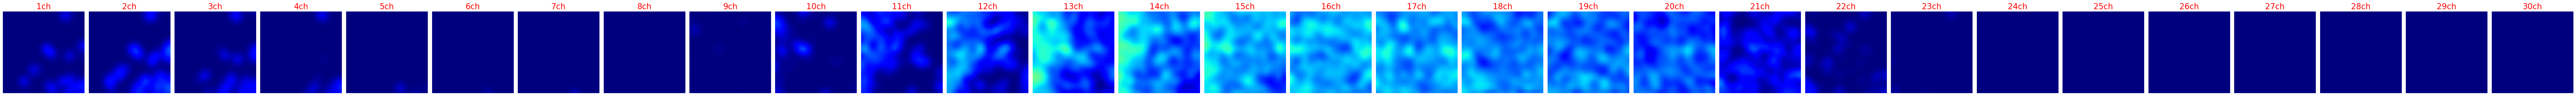

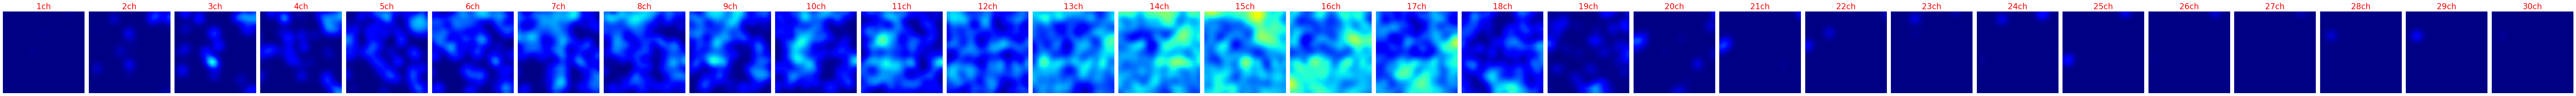

In [70]:
axes_num = common_ex[0].shape[0]
print(axes_num)

for index in range(len(common_ex)):
    data = common_ex[index]
    
    fig, axes = plt.subplots(1, axes_num, figsize=(axes_num*3, 1*4))
    for j, data_segment in enumerate(data):
        axes[j].imshow(data_segment, vmin=0, vmax=1, cmap="jet")
        axes[j].axis("off")
        axes[j].set_title(f"{j+1}ch", fontsize=20, color='red')
        
    # fig.suptitle(f"Data No.{index}, judge: {judgement_list[len(test_bubble):][index]}", fontsize=30, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"common_ex_channel_map_{index}.png")
    plt.show()

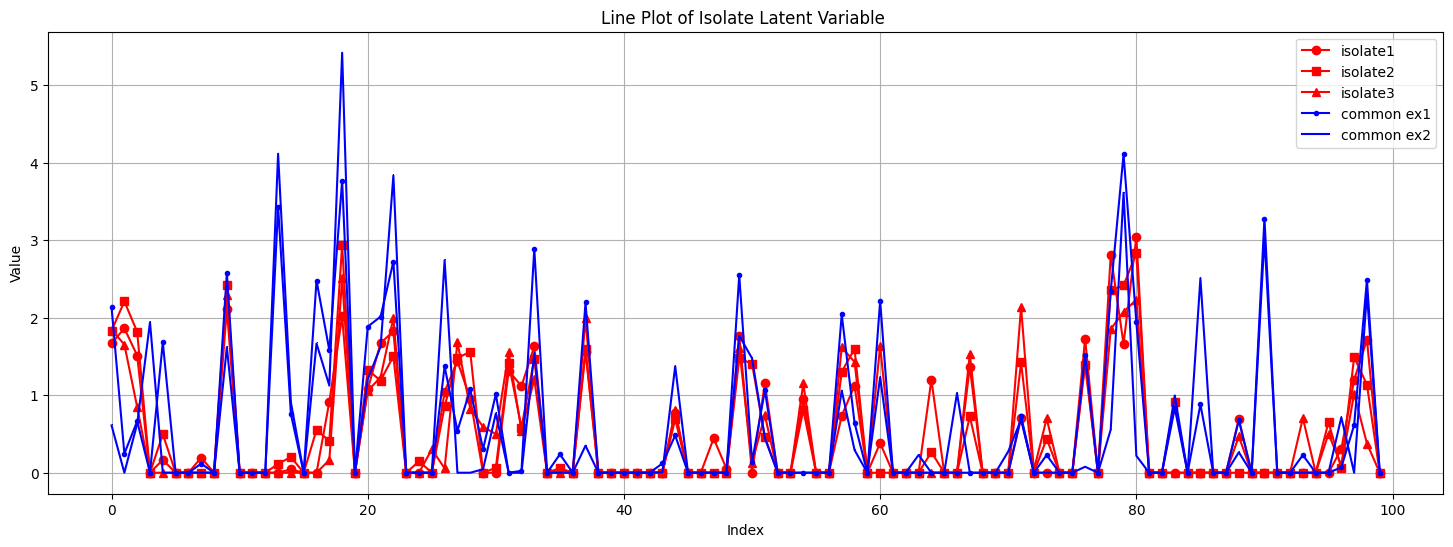

In [71]:
# 3つの配列を定義
data1 = isolate_latent[0]
data2 = isolate_latent[1]
data3 = isolate_latent[2]
data4 = all_data_set[ex_num1]
data5 = all_data_set[ex_num2]


# グラフのプロット（markerを設定すると、各データ点の位置が分かりやすくなります）
plt.figure(figsize=(18, 6))
plt.plot(data1, label='isolate1', marker='o', color="r")
plt.plot(data2, label='isolate2', marker='s', color="r")
plt.plot(data3, label='isolate3', marker='^', color="r")
plt.plot(data4, label='common ex1', marker='.', color="b")
plt.plot(data5, label='common ex2', marker=',', color="b")


# グラフの装飾
plt.title('Line Plot of Isolate Latent Variable ')  # グラフのタイトル
plt.xlabel('Index')                     # X軸のラベル
plt.ylabel('Value')                     # Y軸のラベル
plt.grid(True)                          # 補助線の表示
plt.legend()                            # 凡例（データラベル）の表示


# グラフを表示
plt.savefig("isolate_and_common_latet_plot.png")
plt.show()